# Solving a HANK Model: From Equations to Krusell--Smith in Julia

This notebook solves a heterogeneous-agent New Keynesian (HANK) model with the Krusell--Smith algorithm. It is organized into four parts:

1. **Model:** household behavior, firm pricing, monetary and fiscal policy, market clearing, and equilibrium;
2. **Julia implementation:** calibration, state grids, and reusable numerical routines;
3. **Solution blocks:** the NKPC, household EGM, market clearing, distribution dynamics, and forecasting regressions;
4. **KS fixed point:** the outer iteration, convergence diagnostics, and generalized impulse responses.

The main equations and algorithmic steps remain visible in the notebook; reusable functions are collected in `src/`.


## 1. Julia setup


In [1]:
# Locate and activate the repository environment, then load shared utilities.
using Pkg

# Walk upward so the notebook works from either the repository root or notebooks/.
function find_project_root(start_dir=pwd())
    dir = abspath(start_dir)
    while true
        if isfile(joinpath(dir, "Project.toml"))
            return dir
        end
        parent = dirname(dir)
        parent == dir && error("Could not find Project.toml from $(start_dir)")
        dir = parent
    end
end

# Activate the pinned project before importing dependencies.
project_root = find_project_root()
Pkg.activate(project_root)

# Load numerical, plotting, and model packages.
using LinearAlgebra
using Statistics
using Random
using Printf
using Serialization
using Plots
using HANK

# Load the small-grid and reference calibration helpers.
include(joinpath(project_root, "scripts", "config.jl"))

# Use consistent plotting defaults throughout the notebook.
default(
    size=(760, 430),
    linewidth=2,
    framestyle=:box,
    legend=:best,
    gridalpha=0.25,
)

# Keep expensive intermediate solutions outside version control.
cache_dir = joinpath(project_root, "output", "cache")
mkpath(cache_dir)

# Report the active runtime; production EGM requires multiple threads.
println("Project root: ", project_root)
println("Julia version: ", VERSION)
println("Julia threads: ", Threads.nthreads())
if Threads.nthreads() == 1
    @warn(
        "The current kernel has one thread. Model exposition and small-grid checks can run, " *
        "and existing caches can be loaded. To recompute production EGM, switch to the threaded kernel described above.",
    )
end


Project root: 

  Activating project at `c:\Users\86132\Desktop\Yuxuan ZHAO\minnesota\Research\HANK`


c:\Users\86132\Desktop\Yuxuan ZHAO\minnesota\Research\HANK
Julia version: 1.12.5
Julia threads: 16


## 2. Model

### 2.1 Fundamentals

A HANK model combines two blocks:

- **Heterogeneous households:** heterogeneous households who can self-insure only with a single bond.
- **New Keynesian firms:** monopolistically competitive firms set optimal price with price-adjustment costs.

This is a **one-asset, labor-only HANK model without physical capital**. 

- Time is discrete, and households and firms each form a unit-mass continuum. 

- Households trade one-period nominal government bonds for self-insurance against idiosyncratic income risk, there is no physical capital and no complete set of Arrow securities; 

- Firms produce with labor alone, and they set optimal prices every period, facing Rotemberg price-adjustment costs.

- Central bank sets nominal interest rate by Taylor rule, government issues one-period nominal bonds to finance transfers, and the government budget is balanced every period.

Key notation is summarized below.

| Symbol | Meaning | Type |
|---|---|---|
| $e_t$ | idiosyncratic labor efficiency | individual exogenous state |
| $z_t$ | aggregate labor productivity | aggregate exogenous state |
| $\eta_t$ | log monetary-policy shock | aggregate exogenous state |
| $\tilde a_t$ | shifted bond holdings | individual endogenous state |
| $\mu_t(\tilde a,e)$ | cross-sectional household distribution | exact aggregate state |
| $c_t,n_t,\tilde a_{t+1}$ | consumption, hours, and saving | household choices |
| $w_t,Y_t,\Pi_t,R_t,d_t$ | wage, output, inflation, real return, and dividends | current equilibrium objects |




### 2.2 Fundamental shocks

The model contains three fundamental shocks, affecting idiosyncratic labor income, aggregate productive capacity, and the stance of monetary policy.

| Shock | Process | Economic role |
|---|---|---|
| $e_{i,t}$ | idiosyncratic labor efficiency | changes household $i$'s effective labor per hour |
| $z_t$ | aggregate TFP | changes labor productivity for all firms |
| $\eta_t$ | log monetary-policy shock | shifts the nominal rate through the Taylor rule |

They follow independent AR(1) processes in logs:

$$
\begin{aligned}
\log e_{i,t+1}&=\rho_e\log e_{i,t}+\varepsilon^e_{i,t+1},\\
\log z_{t+1}&=\rho_z\log z_t+\varepsilon^z_{t+1},\\
\eta_{t+1}&=\rho_\eta\eta_t+\varepsilon^\eta_{t+1}.
\end{aligned}
$$

Define the aggregate exogenous state as

$$
s_t=(z_t,\eta_t),
$$

with finite-state transition matrix

$$
P_s=P_z\otimes P_\eta.
$$


### 2.3 Household problem

Households have CRRA utility:

$$
u(c,n)
=\frac{c^{1-\gamma}}{1-\gamma}
-\frac{n^{1+\phi}}{1+\phi},
$$

Households maximize $E_0\sum_{t=0}^{\infty}\beta^t u(c_t,n_t)$.

#### Budget constraint

Let $b_t$ denote bond wealth carried into period $t$. Household's budget constraint is,

$$
c_t+b_{t+1}
=R_t b_t+w_t e_t n_t+d_t+T_t,
\qquad b_{t+1}\geq0,
$$

where $R_t=\frac{1+i_{t-1}}{\Pi_t}$ is the realized gross real return, $w_te_tn_t$ is labor income, $d_t$ is an equal per-capita dividend, and $T_t$ is a lump-sum transfer. 

In this model, we assume the government keeps real debt fixed at $B$, so

$$
T_t=B-R_tB.
$$

Define shifted assets $\tilde a_t=b_t-B$. We can derive a new household budget constraint:

$$
c_t+\tilde a_{t+1}
=R_t\tilde a_t+w_t e_t n_t+d_t,
\qquad \tilde a_{t+1}\geq-B.
$$

The bond-market condition similarly changes from $\int b\,d\mu=B$ to $\int\tilde a\,d\mu=0$. 

#### Krusell--Smith: aggregate state to summarize distribution

Future prices and variables $R, w, d$ is determined by the market-clearing conditions and thus distribution of households. Set $\mu_t(\tilde a,e)$ as the cross-sectional distribution.

The exact recursive state is therefore $(\tilde a,e,s,\mu,i_{-1})$. The difficulty is that $\mu$ is a distribution over the entire asset--efficiency space and is infinite-dimensional. 

We use the Krusell--Smith approximation, setting aggregate state

$$
X_t=(w_t,Y_t)
$$

to summarize how the distribution affects future equilibrium. 

For current aggregate shock $s=(z,\eta)$, and candidate next-period shock $s'=(z',\eta')$, the KS forecasting rule is

$$
\begin{aligned}
\log \widehat W_{t+1}(s';s,X)
&=\alpha_0^W+\alpha_1^W\log z'+\alpha_2^W\eta'+\alpha_3^W\log z+\alpha_4^W\eta+\alpha_5^W\log w+\alpha_6^W\log Y \\

\log \widehat Y_{t+1}(s';s,X)
&=\alpha_0^Y+\alpha_1^Y\log z'+\alpha_2^Y\eta'+\alpha_3^Y\log z+\alpha_4^Y\eta+\alpha_5^Y\log w+\alpha_6^Y\log Y .
\end{aligned}
$$

#### Bellman equation

Define nonlabor cash on hand as

$$
m_t\equiv R_t\tilde a_t+d_t.
$$


Given current state $(m,e,s,X)$ and the forecasting rule $\widehat X'(s';s,X)$, interest rate rule $\widehat R'(s';s,X)$, the household's Bellman equation is

$$
\begin{aligned}
V(m,e,s,X)
=\max_{c,n,\tilde a'}\quad&
u(c,n)
+\beta\sum_{e'}\sum_{s'}
\pi_e(e'|e)\pi_s(s'|s)
V(m',e',s',X')\\
\text{s.t.}\quad&
c+\tilde a'=m+w e n,\\
&\tilde a'\geq-B,\qquad c>0,\\
&X'=\widehat X'(s';s,X),\\
&m'=\widehat R'(s';s,X)\tilde a'
+d(s',X').
\end{aligned}
$$

#### Interest rate rule

Given firm optimal pricing function, we have inflation rule $\Pi(s,X)$, the Taylor rule has set its gross nominal return:

$$
1+i_t
=\bar R\,\Pi(s,X)^{\varphi_\pi}\exp(\eta).
$$

At repayment in $t+1$, this nominal payoff is deflated by next period's price growth. Conditional on $s'$,

$$
\begin{aligned}
\widehat R_{t+1}(s';s,X)
&=\frac{1+i_t}
{\widehat\Pi'(s';s,X)}\\
&=\bar R\,
\frac{\Pi(s,X)^{\varphi_\pi}\exp(\eta)}
{\Pi\!\left(
s',\widehat X'(s';s,X)
\right)} .
\end{aligned}
$$



### 2.4 Firm problem

#### Final-good demand

A competitive final-good producer combines a continuum of differentiated intermediate goods with a CES technology:

$$
Y_t
=\left[
\int_0^1 y_{j,t}^{\frac{\epsilon-1}{\epsilon}}dj
\right]^{\frac{\epsilon}{\epsilon-1}},
\qquad \epsilon>1.
$$

Cost minimization problem is:

$$
\begin{aligned}
\min_{y_{j,t}}\int_0^1p_{j,t}y_{j,t}dj \quad\text{s.t.}\quad \\
Y_t
=\left[
\int_0^1 y_{j,t}^{\frac{\epsilon-1}{\epsilon}}dj
\right]^{\frac{\epsilon}{\epsilon-1}}.
\end{aligned}
$$

 implies the aggregate price index and demand for variety $j$:

$$
P_t
=\left[
\int_0^1p_{j,t}^{1-\epsilon}dj
\right]^{\frac{1}{1-\epsilon}},
\qquad
y_{j,t}
=\left(\frac{p_{j,t}}{P_t}\right)^{-\epsilon}Y_t.
$$

#### Intermediate firms and current profits

Intermediate firm $j$ produces with labor only:

$$
y_{j,t}=z_t\ell_{j,t},
\qquad
\ell_{j,t}
=\frac{1}{z_t}
\left(\frac{p_{j,t}}{P_t}\right)^{-\epsilon}Y_t.
$$

It inherits last period's price $p_{j,t-1}$ and pays a Rotemberg cost when changing its price. Measured in units of the final good, current profits are

$$
\mathcal D_{j,t}
=\left[
\left(\frac{p_{j,t}}{P_t}\right)^{1-\epsilon}
-\frac{w_t}{z_t}
\left(\frac{p_{j,t}}{P_t}\right)^{-\epsilon}
-\frac{\kappa}{2}
\left(\frac{p_{j,t}}{p_{j,t-1}}-1\right)^2
\right]Y_t.
$$

A larger $\kappa$ makes prices more rigid; when $\kappa=0$, prices are flexible.

#### Dynamic price setting

Pricing is dynamic. Given current state $(s,X,P)$ and PLM $\widehat X'(s';s,X)$, the firm's recursive problem is

$$
W(p_{-1}, s,X,P)
=\max_p\left\{
W(p,s',\widehat X'(s';s,X),P')\mid s,X,P
\right\}
$$

The model assumes a constant firm discount factor $\beta_F$, and maximizes the expected discounted sum of profits. 

#### Symmetric equilibrium and the nonlinear NKPC

The individual firm must first optimize while treating the aggregate price index $P_t$ as given. Symmetry is imposed only after solving the individual pricing problem:

$$
p_{j,t}=P_t,
\qquad
y_{j,t}=Y_t,
\qquad
\Pi_t
=\frac{P_t}{P_{t-1}}
=\frac{p_{j,t}}{p_{j,t-1}},
\qquad
Y_t=z_tN_t.
$$

Differentiating the dynamic pricing problem and then imposing these conditions gives the nonlinear New Keynesian Phillips curve:

$$
(1-\epsilon)+\epsilon\frac{w_t}{z_t}
-\kappa(\Pi_t-1)\Pi_t
+\beta_F E_t\!\left[
\frac{Y_{t+1}}{Y_t}
\kappa(\Pi_{t+1}-1)\Pi_{t+1}
\right]=0.
$$

Under flexible prices, the equation reduces to

$$
\frac{w_t}{z_t}=\frac{\epsilon-1}{\epsilon},
$$

so real marginal cost equals the inverse desired markup. Given the KS forecasts for future wages and output, the nonlinear NKPC defines the equilibrium inflation policy $\Pi(s,X)$.

#### Dividends and resource costs

In symmetric equilibrium, aggregate real revenue is $Y_t$, the wage bill is $\frac{w_t}{z_t}Y_t$, and Rotemberg costs absorb final goods. Per-capita dividends are therefore

$$
d_t
=\left[
1-\frac{w_t}{z_t}
-\frac{\kappa}{2}(\Pi_t-1)^2
\right]Y_t.
$$

Thus price adjustment costs affect both firm pricing and the resources distributed to households. They are treated as real resource costs in the model solved below.


### 2.5 Policy rules: monetary and fiscal policy

#### Monetary policy

The monetary authority follows the Taylor rule

$$
1+i_t=\bar R\,\Pi_t^{\varphi_\pi}\exp(\eta_t).
$$

Here $i_t$ is the one-period net nominal rate from $t$ to $t+1$, $\bar R$ is the target gross nominal rate, and $\varphi_\pi$ is the inflation coefficient. T

The Fisher equation is

$$
R_{t+1}=\frac{1+i_t}{\Pi_{t+1}}
=\bar R
\frac{\Pi_t^{\varphi_\pi}\exp(\eta_t)}
{\Pi_{t+1}}.
$$

The nominal rate $i_t$ is known at date $t$, whereas $R_{t+1}$ is known only after $\Pi_{t+1}$ is realized. 

This timing lets monetary policy generate intertemporal-substitution and redistribution effects through nominal household bonds. The baseline sets $\bar R$ slightly below $1/\beta$ to prevent unconstrained household wealth from drifting upward and to help sustain a stationary distribution.

#### Fiscal policy

The fiscal authority keeps real government debt fixed:

$$
B_t=B.
$$

Government budget balance implies: 
$$
T_t=B-R_tB
$$


### 2.6 Timing within a period

 At the start of period $t$, the predetermined objects are

$$
\left(\mu_t,\{\tilde a_{i,t},e_{i,t}\}_i,i_{t-1}\right).
$$

Events then occur as follows:

1. **Shocks are realized.** Every household observes $s_t=(z_t,\eta_t)$ and its own $e_{i,t}$.
2. **Current prices, returns, and the policy rate are jointly determined.** Given $\mu_t$ and candidate $X_t=(w_t,Y_t)$, firm pricing gives $\Pi_t$. The inherited rate $i_{t-1}$ and current inflation imply $R_t=(1+i_{t-1})/\Pi_t$, and firm profits imply $d_t$. Within the same candidate equilibrium, the public Taylor rule sets $1+i_t=\bar R\Pi_t^{\varphi_\pi}\exp(\eta_t)$.
3. **Households choose.** Cash on hand is $m_{i,t}=R_t\tilde a_{i,t}+d_t$. Households know $i_t$ but not $\Pi_{t+1}$, so they choose $(c_{i,t},n_{i,t},\tilde a_{i,t+1})$ while integrating over $R_{t+1}=(1+i_t)/\Pi_{t+1}$.
4. **Markets clear.** The bond and labor conditions jointly select the equilibrium $(w_t,Y_t)$. Steps 2--4 and the Taylor rule form a current-period fixed point; the central bank does not announce an unexpected rate after households have chosen.
5. **The state advances.** Markov transitions draw $e_{i,t+1}$ and $s_{t+1}$; the saving policy and $P_e$ map $\mu_t$ into $\mu_{t+1}$.
6. **The next real return is realized.** Once $\Pi_{t+1}$ is known, $R_{t+1}=(1+i_t)/\Pi_{t+1}$.




### 2.7 Equilibrium Definition



#### Distribution state and law of motion

Let $\mu_t(\tilde a,e)$ be the joint distribution of shifted assets and efficiency. Given saving policy $h_a$, its law of motion is

$$
\mu_{t+1}(A_a\times A_e)
=
\int
\sum_{e'}
\mathbf 1\!\left\{
h_a(m_t(\tilde a),e,s_t,X_t)\in A_a
\right\}
\mathbf 1\{e'\in A_e\}
\pi_e(e'|e)\,d\mu_t(\tilde a,e).
$$

Write this mapping as

$$
\mu_{t+1}
=\mathcal T(\mu_t,h_a,s_t,X_t,P_e).
$$


#### Market clearing and feasibility

Given $\mu_t$, the two unknown aggregates $(w_t,Y_t)$ solve

$$
\int h_a(m_t,e,s_t,X_t)\,d\mu_t=0
\qquad\text{(bond market)},
$$

$$
\int e\,h_n(m_t,e,s_t,X_t)\,d\mu_t
=\frac{Y_t}{z_t}
\qquad\text{(labor market)}.
$$

The first condition is equivalent to average original bond holdings of $B$; the second equates effective labor supply with firm demand. Real-resource-cost dividends imply

$$
C_t\equiv\int c_t\,d\mu_t,
\qquad
C_t+\frac{\kappa}{2}(\Pi_t-1)^2Y_t=Y_t.
$$

This resource constraint is not a third independent market-clearing equation. It will automatically hold because of Walras' law.

#### Krusell--Smith perceived laws of motion

Exact equilibrium uses the full distribution $\mu_t$ as an aggregate state. Abstractly, the true mapping is

$$
X_{t+1}=\mathcal G(\mu_t,s_t,s_{t+1},X_t).
$$

Because $\mu_t$ is infinite-dimensional, KS summarizes its equilibrium effects with $X_t=(w_t,Y_t)$ and assumes, for $q\in\{w,Y\}$,

$$
\begin{aligned}
\log \widehat q_{t+1}(s_{t+1};s_t,X_t)
=\;&\alpha_0^q+\alpha_1^q\log z_{t+1}
+\alpha_2^q\eta_{t+1}\\
&+\alpha_3^q\log z_t+\alpha_4^q\eta_t
+\alpha_5^q\log w_t+\alpha_6^q\log Y_t.
\end{aligned}
$$


#### Formal definition

Given $\mu_0$ and $i_{-1}$, a KS approximate recursive equilibrium is

$$
\left\{
V,\;h_a,\;h_n,\;\Pi,\;d,\;R,\;
\mathcal H_w,\;\mathcal H_Y,\;
\{w_t,Y_t,\mu_t\}_{t\geq0}
\right\}
$$

satisfying:

1. **Household optimality.** Given prices, dividends, policy institutions, and forecasting rules, $V$ solves the household Bellman equation and $h_a,h_n$ are optimal policy functions.
2. **Firm optimality.** Given aggregate forecasts, $\Pi(s,X)$ satisfies the forward-looking pricing problem and NKPC, and $d(s,X)$ is consistent with profits.
3. **Policy-rule consistency.** The nominal rate satisfies the Taylor rule, $R_t=(1+i_{t-1})/\Pi_t$, and the government budget holds with $B_t=B$.
4. **Market clears.** Bond market and labor market clears.
6. **Distribution consistency.** $\mu_{t+1}=\mathcal T(\mu_t,h_a,s_t,X_t,P_e)$.
7. **Forecast-rule consistency.** Within the chosen log-linear family, $\mathcal H_w$ and $\mathcal H_Y$ are the best forecasting rules on the equilibrium simulation paths that they induce.



### 2.8 Model architecture: inner equilibrium and outer state transition

The figure condenses the equilibrium definition above. Inside the dashed **inner-equilibrium** block, the PLM supplies aggregate forecasts for each future shock branch; firm pricing gives $\Pi_t=\Pi(s_t,X_t;\mathcal H)$; the policy-and-price block gives $i_t$, $R_t$, and $d_t$; and household policies give $(c_t,n_t,\tilde a_{t+1})=h(m_t,e_t,s_t,X_t;\Pi,\mathcal H)$. Bond- and labor-market clearing jointly determine $(w_t,Y_t)$.

The **outer transition** advances the actual economy from $t$ to $t+1$. Saving and efficiency transitions map $\mu_t$ into $\mu_{t+1}=\mathcal T(\mu_t,h_a,s_t;P_e)$, Markov shocks determine $s_{t+1}$, and the current Taylor-rule choice $i_t$ becomes next period's inherited nominal rate. Here “outer” denotes the economic state transition, not the KS coefficient update.


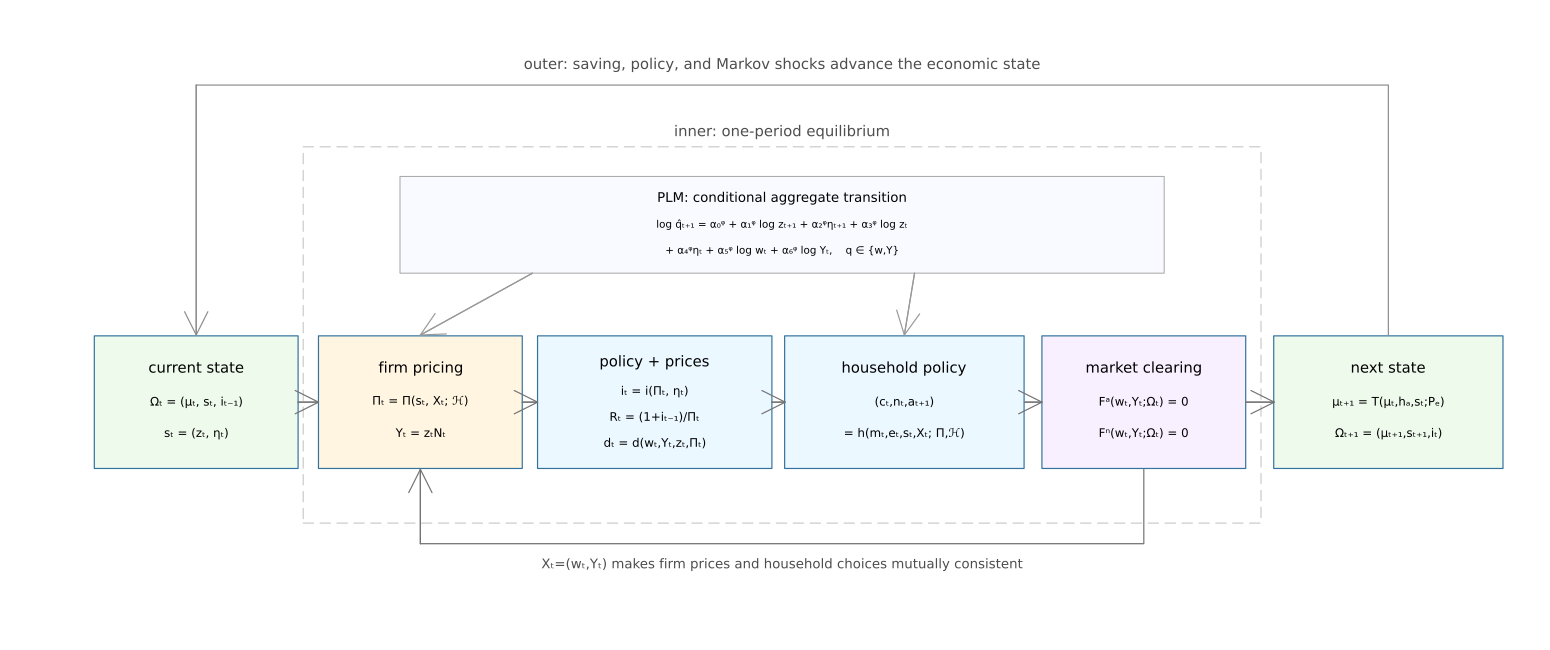

In [2]:
# Draw the architecture; load the helper directly if the active package is stale.
architecture_plot = if isdefined(HANK, :plot_hank_model_architecture)
    HANK.plot_hank_model_architecture()
else
    if !isdefined(Main, :plot_hank_model_architecture)
        include(joinpath(project_root, "src", "diagram.jl"))
    end
    plot_hank_model_architecture()
end

architecture_plot


### 2.9 Numerical algorithm: inner and outer loops

The computation separates “solve the economy under given forecasting rules” from “update those rules with simulated data,” as in the KS1998 solver.

#### Inner loops: given $(\alpha^w,\alpha^Y)$

1. On the $(z,\eta,w,Y)$ grid, iterate on $x=\kappa(\Pi-1)\Pi$ to solve the forward-looking NKPC fixed point.
2. Given future prices, inflation, and real returns, solve household policies $(h_a,h_n)$ with the Euler equation and EGM.
3. Given the current distribution, use a two-dimensional Newton method each period to find $(w_t,Y_t)$ that clears the bond and labor markets.
4. Advance the distribution with household policies and a Young lottery to obtain $\{w_t,Y_t,\Pi_t,R_t,\mu_t\}_{t=1}^T$.

#### Outer loop: update aggregate laws of motion

1. Discard the burn-in sample.
2. Run separate OLS regressions for wages and output to obtain $\widehat\alpha^w$ and $\widehat\alpha^Y$.
3. Apply the damped update

$$
\alpha^{q,\mathrm{new}}
=(1-\lambda)\alpha^{q,\mathrm{old}}
+\lambda\widehat\alpha^q,
\qquad q\in\{w,Y\}.
$$

4. Hold the aggregate shock path fixed and repeat the inner loops and OLS until the forecasting coefficients stabilize.

A high regression $R^2$ is not sufficient. This notebook also checks the KS coefficient distance, NKPC and EGM errors, market-clearing residuals, the resource constraint, Den Haan recursive forecast errors, and whether distributions or prices reach grid boundaries.

We now implement each block in Julia.


## 3. Calibration and state grids

The following calibration uses the reference model's preferences, firm parameters, shocks, and production grids. The only economic convention changed from the legacy benchmark is that Rotemberg costs are deducted from dividends as real resource costs.

### 3.1 What does each structural parameter control?

| Parameter | Baseline | Economic meaning |
|---|---:|---|
| $\beta$ | 0.975 | household patience |
| $\gamma$ | 1 | relative risk aversion |
| $\phi$ | 1 | inverse Frisch elasticity |
| $\beta_F$ | 0.975 | firm discount factor for future profit |
| $\epsilon$ | 10 | elasticity across varieties |
| $\kappa$ | 100 | Rotemberg adjustment cost |
| Dividend accounting | real resource cost | $d=[1-w/z-\kappa(\Pi-1)^2/2]Y$ |
| $\varphi_\pi$ | 1.5 | Taylor-rule response to inflation |
| $\bar R$ | $0.997/0.975$ | Taylor-rule target gross rate |
| $B$ | 5 | government bond supply |
| $(\rho_e,\sigma_e)$ | $(0.6,0.16)$ | persistence and innovation volatility of idiosyncratic efficiency |
| $(\rho_z,\sigma_z)$ | $(0.9,0.07\sqrt{1-0.9^2})$ | persistence and innovation volatility of TFP |
| $(\rho_\eta,\sigma_\eta)$ | $(0.9,0.002\sqrt{1-0.9^2})$ | persistence and innovation volatility of the log monetary shock |

The production configuration uses 11 TFP states, 11 monetary-shock states, 100 household asset nodes, 500 distribution nodes, and a 2,000-period simulation.

These grids resolve persistent aggregate shocks, policy curvature near the borrowing constraint, and enough state variation for the seven-regressor OLS equations.


In [3]:
# Build the reference calibration and its discretized state grids.
par = reference_config()

model = HANKModel(par)

# Report the economic calibration and the size of the state space.
println("Borrowing limit a_min = ", asset_min(par))
println("Steady-state wage      = ", round(model.steady_wage, digits=4))
println("Steady real return     = ", round(model.steady_return, digits=6))
println("Rotemberg cost in dividend = ", par.include_rotemberg_in_dividends)
println("Household asset nodes  = ", par.n_assets)
println("Distribution nodes     = ", par.n_histogram_assets)
println("Aggregate shock nodes  = ", (par.n_z, par.n_eta))
println("Wage/output nodes      = ", (par.n_wages, par.n_outputs))
println("Simulation / burn-in   = ", (par.simulation_length, par.burn_in))
println("Policy array size      = ",
    (length(model.cash_grid), par.n_e, par.n_wages, par.n_outputs, par.n_z, par.n_eta))
println("Number of policy nodes = ",
    prod((length(model.cash_grid), par.n_e, par.n_wages, par.n_outputs, par.n_z, par.n_eta)))
# Count reachable aggregate states after dropping zero-probability transitions.
future_support = [
    length(model.nonzero_z_destinations[iz]) *
    length(model.nonzero_eta_destinations[ieta])
    for iz in 1:par.n_z, ieta in 1:par.n_eta
]
println("Nonzero aggregate destinations per state = ",
    extrema(future_support))


Borrowing limit a_min = -5.0
Steady-state wage      = 0.9
Steady real return     = 1.022564
Rotemberg cost in dividend = true
Household asset nodes  = 100
Distribution nodes     = 500
Aggregate shock nodes  = (11, 11)
Wage/output nodes      = (10, 10)
Simulation / burn-in   = (2000, 200)
Policy array size      = (100, 3, 10, 10, 11, 11)
Number of policy nodes = 3630000
Nonzero aggregate destinations per state = (49, 121)


### 3.2 Tauchen discretization

The three AR(1) processes describe idiosyncratic efficiency, TFP, and the monetary-policy shock. 

After discretization, verify that every transition row sums to one, all probabilities are nonnegative, and simulated paths visit multiple states.


In [4]:
z_path_check, eta_path_check = draw_aggregate_paths(model, par)

println("TFP log grid: ", round.(model.log_z_grid, digits=4))
println("Middle-row transition probabilities: ",
    round.(model.transition_z[cld(par.n_z, 2), :], digits=5))
println("Maximum row-sum error: ",
    maximum(abs.(vec(sum(model.transition_z, dims=2)) .- 1.0)))
println("TFP states visited: ", sort(unique(z_path_check)))
println("MP states visited:  ", sort(unique(eta_path_check)))


TFP log grid: [-0.21, -0.168, -0.126, -0.084, -0.042, 0.0, 0.042, 0.084, 0.126, 0.168, 0.21]
Middle-row transition probabilities: [0.0, 0.0, 0.00029, 0.01918, 0.22617, 0.5087, 0.22617, 0.01918, 0.00029, 0.0, 0.0]
Maximum row-sum error: 1.1102230246251565e-16
TFP states visited: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
MP states visited:  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]


## 4. Step 0: Initialize the perceived laws of motion

For $q\in\{w,Y\}$, assume the log-linear PLM

$$
\begin{aligned}
\log \widehat q_{t+1}(s';s,X)
=\;&\alpha_0^q+\alpha_1^q\log z'
+\alpha_2^q\eta'\\
&+\alpha_3^q\log z+\alpha_4^q\eta
+\alpha_5^q\log w+\alpha_6^q\log Y.
\end{aligned}
$$

We initialize the PLM with constant forecasts $\widehat w_{t+1}=\bar w$ and $\widehat Y_{t+1}=1$. The corresponding coefficient vectors are

$$
b_w^{(0)}
=\bigl(\log\bar w,0,0,0,0,0,0\bigr),
\qquad
b_Y^{(0)}
=(0,0,0,0,0,0,0),
$$

where

$$
\bar w=\frac{\epsilon-1}{\epsilon}=0.9,
\qquad
\log\bar w=\log(0.9)\approx-0.105360516.
$$


In [5]:
# Begin KS from neutral constant laws; use supplied coefficients only for comparison.
constant_rules = initial_forecast_rules(model)
published_converged_rules = reference_forecast_rules()
rules = constant_rules

# Compare the neutral initial laws with the supplied near-converged laws.
coefficient_names = [
    "constant", "log z_next", "log eta_next", "log z",
    "log eta", "log wage", "log output",
]

println(
    " term          | reference initial wage | reference initial output | published wage | published output",
)
println(repeat("-", 104))
for j in eachindex(coefficient_names)
    @printf(
        " %-13s | %22.9f | %24.9f | %14.9f | %16.9f\n",
        coefficient_names[j],
        rules.wage.coefficient[j],
        rules.output.coefficient[j],
        published_converged_rules.wage.coefficient[j],
        published_converged_rules.output.coefficient[j],
    )
end

# Verify that the active rules are the intended constant start.
@assert rules.wage.coefficient ==
    [log(model.steady_wage), 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
@assert rules.output.coefficient == zeros(7)

 term          | reference initial wage | reference initial output | published wage | published output
--------------------------------------------------------------------------------------------------------
 constant      |           -0.105360516 |              0.000000000 |   -0.034186963 |     -0.015151639
 log z_next    |            0.000000000 |              0.000000000 |    0.781624581 |      0.887729675
 log eta_next  |            0.000000000 |              0.000000000 |   -2.271895478 |     -1.103905874
 log z         |            0.000000000 |              0.000000000 |   -0.053056386 |     -0.391982895
 log eta       |            0.000000000 |              0.000000000 |    1.320496161 |      0.583963283
 log wage      |            0.000000000 |              0.000000000 |    0.945318118 |      0.062680723
 log output    |            0.000000000 |              0.000000000 |   -0.771977790 |      0.385548361


## 5. Step 1: Solve the NKPC

Given the PLM, the firm's symmetric-equilibrium FOC is the nonlinear NKPC

$$
\begin{aligned}
0=\;&(1-\epsilon)+\epsilon\frac{w}{z}
-\kappa\bigl(\Pi(s,X)-1\bigr)\Pi(s,X)\\
&+\beta_F\sum_{s'}\pi_s(s'|s)
\frac{\widehat Y'(s')}{Y}
\kappa\Bigl(\Pi\bigl(s',X'(s')\bigr)-1\Bigr)
\Pi\bigl(s',X'(s')\bigr).
\end{aligned}
$$

Define

$$
x(s,X)
\equiv
\kappa\bigl(\Pi(s,X)-1\bigr)\Pi(s,X).
$$

Given a current guess $x^{\mathrm{old}}$, one NKPC fixed-point update is

$$
x^{\mathrm{new}}(s,X)
=(1-\epsilon)+\epsilon\frac{w}{z}
+\beta_F\sum_{s'}\pi_s(s'|s)
\frac{\widehat Y'(s')}{Y}
x^{\mathrm{old}}\bigl(s',X'(s')\bigr).
$$

The implementation applies damping,

$$
x^{(k+1)}
=(1-\lambda)x^{(k)}+\lambda x^{\mathrm{new}},
\qquad 0<\lambda\leq1,
$$

and repeats until the sup-norm update is below tolerance. Inflation is recovered from the positive root of $x=\kappa(\Pi^2-\Pi)$:

$$
\Pi(s,X)
=\frac{1+\sqrt{1+4x(s,X)/\kappa}}{2}.
$$

Actually, we can also use Value Function Iteration (VFI) to solve the firm's recursive pricing problem and get $\Pi(s,X)$. The VFI approach is more robust but slower.

NKPC steps = 500, final sup error = 1.068e-04, converged = false
NKPC wall time = 8.84 seconds
Inflation policy range = [0.900000, 1.100000]


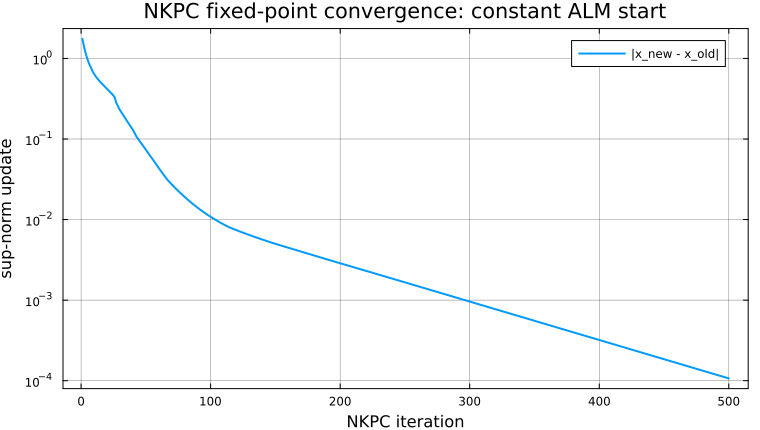

In [6]:
# Solve the forward-looking NKPC under the current aggregate forecasting rules.
nkpc_start_time = time()
nkpc = solve_nkpc(
    model,
    par,
    rules;
    max_steps=500,
    damping=0.30,
    tolerance=par.nkpc_tolerance,
)
nkpc_wall_seconds = time() - nkpc_start_time

# Report convergence and the inflation range implied by the fixed point.
@printf(
    "NKPC steps = %d, final sup error = %.3e, converged = %s\n",
    length(nkpc.error_history),
    last(nkpc.error_history),
    string(nkpc.converged),
)
@printf("NKPC wall time = %.2f seconds\n", nkpc_wall_seconds)
@printf(
    "Inflation policy range = [%.6f, %.6f]\n",
    minimum(nkpc.inflation_policy),
    maximum(nkpc.inflation_policy),
)

# Visualize contraction of the NKPC fixed-point update.
plot(
    nkpc.error_history,
    yscale=:log10,
    xlabel="NKPC iteration",
    ylabel="sup-norm update",
    title="NKPC fixed-point convergence: constant ALM start",
    label="|x_new - x_old|",
)

## 6. Step 2: Solve household policies by EGM

### 6.1 EGM update

This section turns the household first-order conditions into a numerical policy update. Fix the current aggregate state $(s,X)$, current efficiency $e$, and a candidate next-period shifted-asset node $\tilde a'$.

The intratemporal labor condition is

$$
n^\phi=we\,c^{-\gamma},
$$

and the Kuhn--Tucker condition for saving is

$$
c^{-\gamma}
\geq
\beta E_t\!\left[R_{t+1}c_{t+1}^{-\gamma}\right].
$$

Equality holds at an interior choice $\tilde a'>-B$. The inequality can be strict when the borrowing constraint binds.

One EGM update proceeds as follows.

1. **Evaluate every future branch.** For each $(e',s')$, use the perceived aggregate law and current candidate saving to construct

   $$
   X'=\widehat X_{t+1}(s';s,X),
   \qquad
   m'=\widehat R_{t+1}(s';s,X)\tilde a'+d(s',X').
   $$

   Interpolate the previous consumption policy at that future state:

   $$
   c'=h_c^{\mathrm{old}}(m',e',s',X').
   $$

2. **Compute the expected marginal value of saving.** Define

   $$
   \mathcal M(\tilde a';e,s,X)
   \equiv
   \beta\sum_{e'}\sum_{s'}
   \pi_e(e'|e)\pi_s(s'|s)
   \widehat R_{t+1}(s';s,X)
   \left[c'\right]^{-\gamma}.
   $$

3. **Recover current consumption from the Euler equation.** At an interior point,

   $$
   c^{-\gamma}=\mathcal M(\tilde a';e,s,X),
   \qquad
   c=\mathcal M(\tilde a';e,s,X)^{-1/\gamma}.
   $$

4. **Recover current labor from the static FOC.** In general,

   $$
   n=\left(we\,c^{-\gamma}\right)^{1/\phi}.
   $$

   The baseline calibration sets $\gamma=\phi=1$, so this becomes

   $$
   n=\frac{we}{c}.
   $$

5. **Back out the endogenous current cash-on-hand node.** Rearranging the current budget constraint gives

   $$
   m^{\mathrm{endo}}
   =c+\tilde a'-wen.
   $$

   Hence each exogenous saving node $\tilde a'$ generates one pair

   $$
   \left(m^{\mathrm{endo}}(\tilde a'),\tilde a'\right).
   $$

6. **Return to the fixed cash grid.** Sort the endogenous nodes if necessary and interpolate the pairs above onto each fixed node $m_j$:

   $$
   h_a^{\mathrm{new}}(m_j,e,s,X)
   =\operatorname{Interp}\!\left(
   \{m^{\mathrm{endo}}(\tilde a'_k),\tilde a'_k\}_k;
   m_j
   \right).
   $$

7. **Handle the borrowing-constrained region.** If $m_j$ lies below the smallest endogenous node, impose

   $$
   h_a^{\mathrm{new}}(m_j,e,s,X)=-B.
   $$

   The Euler equality need not hold there. Instead recover consumption and labor directly from the budget constraint and labor FOC. For any given $(m,\tilde a')$, define

   $$
   Q\equiv m-\tilde a'.
   $$

   Under $\gamma=\phi=1$,

   $$
   c=Q+wen
   =Q+\frac{(we)^2}{c},
   $$

   so

   $$
   c^2-Qc-(we)^2=0,
   \qquad
   c=\frac{Q+\sqrt{Q^2+4(we)^2}}{2},
   \qquad
   n=\frac{we}{c}.
   $$

The positive root guarantees $c>0$. After interpolation and the constraint correction, the update returns the saving, consumption, and labor policies

$$
h_a(m,e,s,X),
\qquad
h_c(m,e,s,X),
\qquad
h_n(m,e,s,X).
$$



EGM     1 | sup error 7.532e+01 | elapsed 0.8 s | threads 16
EGM    10 | sup error 1.052e+00 | elapsed 4.8 s | threads 16
EGM    20 | sup error 2.703e-01 | elapsed 8.9 s | threads 16
EGM    30 | sup error 1.227e-01 | elapsed 12.9 s | threads 16
EGM    40 | sup error 6.733e-02 | elapsed 17.0 s | threads 16
EGM    50 | sup error 4.125e-02 | elapsed 21.2 s | threads 16
EGM    60 | sup error 2.648e-02 | elapsed 25.3 s | threads 16
EGM    70 | sup error 1.773e-02 | elapsed 29.4 s | threads 16
EGM    80 | sup error 1.212e-02 | elapsed 33.8 s | threads 16
EGM    90 | sup error 8.428e-03 | elapsed 37.9 s | threads 16
EGM   100 | sup error 6.004e-03 | elapsed 42.0 s | threads 16
EGM   110 | sup error 4.275e-03 | elapsed 46.1 s | threads 16
EGM   120 | sup error 3.047e-03 | elapsed 50.2 s | threads 16
EGM   130 | sup error 2.169e-03 | elapsed 54.3 s | threads 16
EGM   140 | sup error 1.546e-03 | elapsed 58.3 s | threads 16
EGM   150 | sup error 1.094e-03 | elapsed 62.5 s | threads 16
EGM   160 |

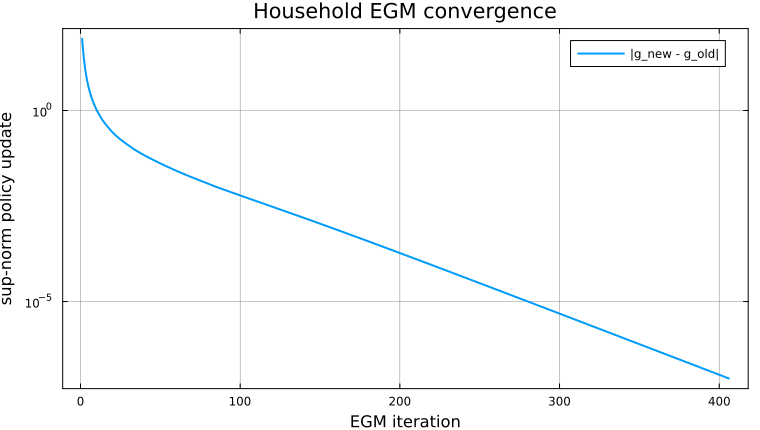

In [7]:
# Cache the expensive production-grid household fixed point by calibration and prices.
household_cache_path = joinpath(cache_dir, "household_resource_cost_constant_start_nkpc500.jls")

# Solve once and store every object needed to validate the cache.
function compute_household_solution()
    Threads.nthreads() > 1 || error(
        "Production-grid EGM requires a threaded Julia kernel; install and select it as described in Section 1.",
    )
    solution = solve_household(
        model,
        nkpc.inflation_policy,
        rules,
        par;
        tolerance=par.egm_tolerance,
        max_iterations=par.egm_max_iterations,
        verbose=true,
        progress_every=10,
    )
    cache_entry = (
        params=par,
        wage_coefficients=copy(rules.wage.coefficient),
        output_coefficients=copy(rules.output.coefficient),
        inflation_policy=copy(nkpc.inflation_policy),
        household=solution,
    )
    serialize(household_cache_path, cache_entry)
    return solution
end

# Reuse the cache only when calibration, forecasts, and inflation policy match.
household = if isfile(household_cache_path)
    try
        cache_entry = deserialize(household_cache_path)
        cache_matches =
            cache_entry.params == par &&
            cache_entry.wage_coefficients == rules.wage.coefficient &&
            cache_entry.output_coefficients == rules.output.coefficient &&
            size(cache_entry.inflation_policy) == size(nkpc.inflation_policy) &&
            maximum(abs.(
                cache_entry.inflation_policy .- nkpc.inflation_policy
            )) < 1e-12
        cache_matches || error("cached policy belongs to another calibration")
        println("Loading cached household policy from ", household_cache_path)
        cache_entry.household
    catch err
        @warn "Household cache is stale; solving again" exception=(
            err,
            catch_backtrace(),
        )
        compute_household_solution()
    end
else
    compute_household_solution()
end

# Report household fixed-point accuracy and runtime.
@printf(
    "EGM iterations = %d, final sup error = %.3e, converged = %s\n",
    length(household.error_history),
    last(household.error_history),
    string(household.converged),
)
@printf("EGM wall time = %.1f seconds using %d threads\n",
    household.elapsed_seconds, household.threads)

# Plot convergence of the saving policy.
plot(
    household.error_history,
    yscale=:log10,
    xlabel="EGM iteration",
    ylabel="sup-norm policy update",
    title="Household EGM convergence",
    label="|g_new - g_old|",
)


### 6.2 Household policy functions

Hold aggregate shocks at their mean and wages and output near steady state, then compare the three idiosyncratic-efficiency states. The asset policy is most curved near the borrowing constraint, motivating the quadratic spacing of the asset grid.


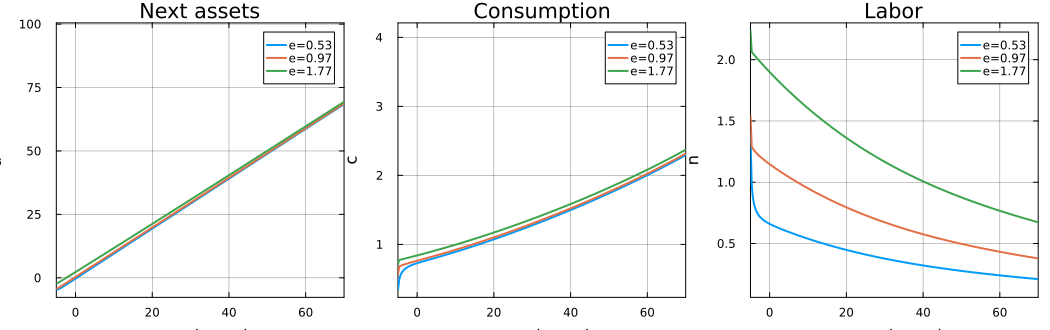

In [8]:
# Bundle the objects expected by the policy-slice diagnostic.
partial_solution = (
    model=model,
    params=par,
    inflation_policy=nkpc.inflation_policy,
    household_policy=household.policy,
)

# Compare saving, consumption, and labor across efficiency states.
policy_plot = plot(layout=(1, 3), size=(1050, 330))
plot_asset_max = 70.0  # Hide only the sparse distribution tail; the solver still uses the full asset grid.
for ie in 1:par.n_e
    slice = policy_slice(partial_solution; productivity_index=ie)
    plot!(
        policy_plot[1],
        slice.assets,
        slice.savings,
        label="e=$(round(model.e_grid[ie], digits=2))",
    )
    plot!(
        policy_plot[2],
        slice.assets,
        slice.consumption,
        label="e=$(round(model.e_grid[ie], digits=2))",
    )
    plot!(
        policy_plot[3],
        slice.assets,
        slice.labor,
        label="e=$(round(model.e_grid[ie], digits=2))",
    )
end
# Apply common axes and labels after adding all policy curves.
plot!(policy_plot[1], title="Next assets", xlabel="current assets", ylabel="a'", xlims=(asset_min(par), plot_asset_max))
plot!(policy_plot[2], title="Consumption", xlabel="current assets", ylabel="c", xlims=(asset_min(par), plot_asset_max))
plot!(policy_plot[3], title="Labor", xlabel="current assets", ylabel="n", xlims=(asset_min(par), plot_asset_max))
policy_plot


## 7. Step 3: Clear two markets and advance the distribution

Given $(\mu_t,s_t,i_{t-1})$, choose $X_t=(w_t,Y_t)$ to satisfy the bond- and labor-market conditions

$$
\begin{aligned}
0
&=\int h_a\bigl(m_t(\tilde a),e,s_t,X_t\bigr)
\,d\mu_t(\tilde a,e),\\
\frac{Y_t}{z_t}
&=\int e\,h_n\bigl(m_t(\tilde a),e,s_t,X_t\bigr)
\,d\mu_t(\tilde a,e).
\end{aligned}
$$

Let $F(X_t)$ collect these two residuals. The code solves $F(X_t)=0$ with a damped two-dimensional Newton method:

$$
X^{(k+1)}
=X^{(k)}-\lambda_k
\left[DF\bigl(X^{(k)}\bigr)\right]^{-1}
F\bigl(X^{(k)}\bigr).
$$

The step size $\lambda_k$ is halved until the residuals decrease, and iteration stops when both market residuals are below $10^{-6}$. After finding $(w_t,Y_t)$, the saving policy and $P_e$ advance the distribution to $\mu_{t+1}$.


In [9]:
# Jointly choose wage and output so the bond and labor markets clear.
# Start from the invariant distribution and central aggregate shocks.
distribution0 = initial_distribution(model, par)
middle_z = cld(par.n_z, 2)
middle_eta = cld(par.n_eta, 2)

clearing0 = clear_markets(
    household.policy,
    nkpc.inflation_policy,
    model,
    distribution0,
    middle_z,
    middle_eta,
    model.steady_wage,
    1.0,
    model.steady_return - 1.0,
    par,
)

# Inspect equilibrium prices and both market residuals.
println("One-period market clearing")
println(repeat("-", 42))
@printf("%-24s %14.8f\n", "real wage", clearing0.wage)
@printf("%-24s %14.8f\n", "output", clearing0.output)
@printf("%-24s %14.8f\n", "gross real return", clearing0.gross_return)
@printf("%-24s %14.8f\n", "gross inflation", clearing0.inflation)
@printf("%-24s %14.3e\n", "bond residual", clearing0.bond_residual)
@printf("%-24s %14.3e\n", "labor residual", clearing0.labor_residual)
@printf("%-24s %14s\n", "Newton converged", string(clearing0.converged))

# Advance the histogram once and verify that probability mass is preserved.
distribution1 = similar(distribution0)
temporary_distribution = similar(distribution0)
advance_distribution!(
    distribution1,
    temporary_distribution,
    distribution0,
    household.policy,
    clearing0.wage,
    clearing0.output,
    clearing0.gross_return,
    clearing0.dividend,
    model,
    middle_z,
    middle_eta,
    par,
)
@printf("Distribution mass after one step = %.12f\n", sum(distribution1))


One-period market clearing
------------------------------------------
real wage                    0.64932756
output                       0.78422891
gross real return            1.02932054
gross inflation              0.99343602
bond residual                -8.354e-10
labor residual               -9.489e-10
Newton converged                   true
Distribution mass after one step = 1.000000000000


## 8. Step 4: Simulate the economy and update the PLM

Starting from the middle shock nodes, draw one aggregate shock path

$$
\{s_t\}_{t=0}^{T}
=
\{(z_t,\eta_t)\}_{t=0}^{T},
\qquad
z_{t+1}\sim P_z(z_t,\cdot),
\quad
\eta_{t+1}\sim P_\eta(\eta_t,\cdot).
$$

Only this aggregate path is sampled. Individual households are not simulated: the histogram and $P_e$ advance the idiosyncratic distribution exactly. At each date, market clearing determines $(w_t,Y_t)$, while the pricing and policy rules determine inflation and returns.


Maximum post-burn market residual = 1.000e+02
Newton convergence share          = 0.056
Mean gross return                 = 1.037763


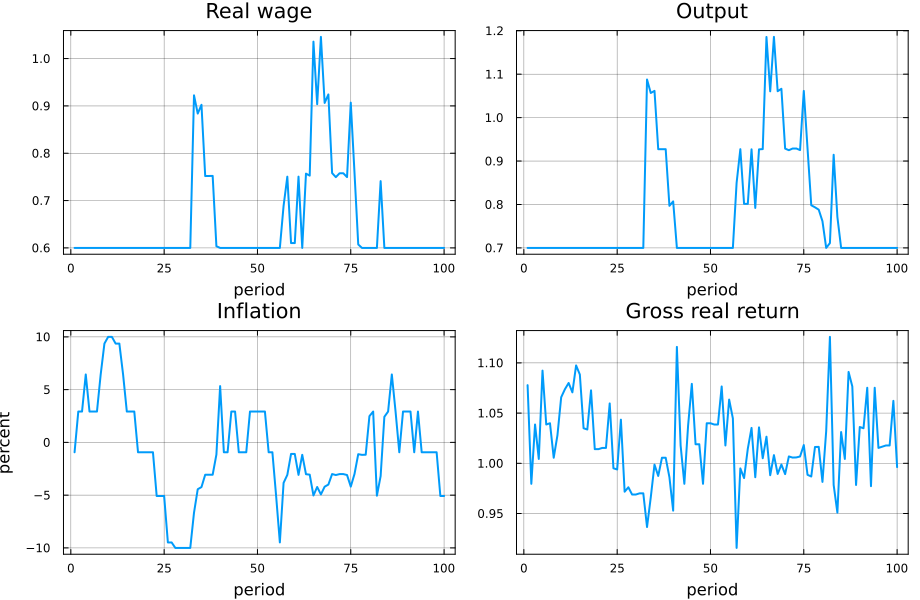

In [10]:
# Simulate under fixed perceived laws, clearing both markets each period.
# Draw one shock history and solve realized equilibrium along the path.
z_path, eta_path = draw_aggregate_paths(model, par)
simulation = simulate_economy(
    household.policy,
    nkpc.inflation_policy,
    rules,
    model,
    par;
    z_path=z_path,
    eta_path=eta_path,
)

# Evaluate market clearing only after the burn-in sample.
post_burn = (par.burn_in + 1):par.simulation_length
max_market_error = maximum(max.(
    abs.(simulation.bond_residual[post_burn]),
    abs.(simulation.labor_residual[post_burn]),
))
market_share = mean(simulation.market_converged[post_burn])

@printf("Maximum post-burn market residual = %.3e\n", max_market_error)
@printf("Newton convergence share          = %.3f\n", market_share)
@printf("Mean gross return                 = %.6f\n",
    mean(simulation.gross_return[post_burn]))

# Plot a short post-burn window for visual diagnostics.
window = (par.burn_in + 1):min(par.burn_in + 100, par.simulation_length)
paths_plot = plot(layout=(2, 2), size=(920, 600), legend=false)
plot!(paths_plot[1], simulation.wage[window], title="Real wage", xlabel="period")
plot!(paths_plot[2], simulation.output[window], title="Output", xlabel="period")
plot!(paths_plot[3], 100 .* (simulation.inflation[window] .- 1),
    title="Inflation", ylabel="percent", xlabel="period")
plot!(paths_plot[4], simulation.gross_return[window],
    title="Gross real return", xlabel="period")
paths_plot


### Update the PLM from the simulated sample

After discarding burn-in observations, fit the PLM in Section 4 by OLS for $q\in\{w,Y\}$. If $\widehat b_q^{\mathrm{OLS}}$ denotes the fitted coefficients, update the rule with damping:

$$
b_q^{\mathrm{new}}
=(1-\lambda)b_q^{\mathrm{old}}
+\lambda\widehat b_q^{\mathrm{OLS}}.
$$


In [11]:
# Regress realized next-period wages and output on the KS state vector.
fitted_rules, forecast_r2 = fit_forecast_rules(simulation, model, par)
one_step_distance = forecast_distance(rules, fitted_rules)

# Compare fitted coefficients with the laws used in simulation.
println("Forecast-rule update")
println(repeat("-", 78))
@printf("R2 wage = %.6f, R2 output = %.6f\n", forecast_r2.wage, forecast_r2.output)
@printf("Coefficient distance = %.6e\n\n", one_step_distance)
println(" term          | wage used | wage fitted | output used | output fitted")
println(repeat("-", 78))
for j in eachindex(coefficient_names)
    @printf(
        " %-13s | %9.4f | %11.4f | %11.4f | %13.4f\n",
        coefficient_names[j],
        rules.wage.coefficient[j],
        fitted_rules.wage.coefficient[j],
        rules.output.coefficient[j],
        fitted_rules.output.coefficient[j],
    )
end

# Apply one damped update instead of replacing the laws outright.
damped_rules = update_forecast_rules(rules, fitted_rules, 0.08)
println("\nAfter damping, wage coefficient update norm = ",
    norm(damped_rules.wage.coefficient - rules.wage.coefficient))


Forecast-rule update
------------------------------------------------------------------------------
R2 wage = 0.931475, R2 output = 0.896877
Coefficient distance = 1.745128e+00

 term          | wage used | wage fitted | output used | output fitted
------------------------------------------------------------------------------
 constant      |   -0.1054 |      0.0044 |      0.0000 |        0.0165
 log z_next    |    0.0000 |      0.1699 |      0.0000 |        0.1556
 log eta_next  |    0.0000 |      0.8170 |      0.0000 |       -0.1498
 log z         |    0.0000 |     -0.1263 |      0.0000 |       -0.0844
 log eta       |    0.0000 |     -1.1561 |      0.0000 |        0.0730
 log wage      |    0.0000 |      0.9914 |      0.0000 |        0.2053
 log output    |    0.0000 |     -0.0398 |      0.0000 |        0.6808

After damping, wage coefficient update norm = 0.1396102386041642


## 9. Step 5: Run the outer KS iteration from a neutral aggregate-rule guess

The preceding steps now form one loop:

```text
constant steady-state forecast rules
        ↓
solve NKPC → solve households by EGM
        ↓
simulate: clear markets + advance distribution
        ↓
OLS wage/output laws
        ↓
damped coefficient update → repeat
```

The initial aggregate laws are $\widehat w'=\bar w$ and $\widehat Y'=1$:
$$
b_w^{(0)}
=\bigl(\log\bar w,0,0,0,0,0,0\bigr),
\qquad
b_Y^{(0)}
=(0,0,0,0,0,0,0),
$$

In [12]:
# Iterate the KS fixed point, reusing a compatible cached solution when available.
ks_cache_path = joinpath(
    cache_dir,
    "hank_resource_cost_dividends_ks120_nkpc20.jls",
)

# Manual cache switch: true = recompute/overwrite; set false after the fresh run to reuse it.
force_recompute_ks = false
# Include every solver choice that changes cache compatibility.
ks_solver_signature = (
    dividend_accounting=:resource_cost,
    initial_policy_mode=:reference_continuation,
    max_ks_iterations=120,
    ks_tolerance=1e-3,
    forecast_damping=0.10,
    nkpc_steps_per_ks=20,
)

# Solve from neutral laws and store fresh-run timing with the result.
function compute_constant_start_ks()
    solved_result = nothing
    start_time = time()
    solved_result = solve_hank(
        par;
        initial_rules=rules,
        max_ks_iterations=ks_solver_signature.max_ks_iterations,
        ks_tolerance=ks_solver_signature.ks_tolerance,
        forecast_damping=ks_solver_signature.forecast_damping,
        nkpc_steps_per_ks=ks_solver_signature.nkpc_steps_per_ks,
        verbose=true,
    )
    elapsed_seconds = time() - start_time
    cache_entry = (
        params=par,
        initial_wage_coefficients=copy(rules.wage.coefficient),
        initial_output_coefficients=copy(rules.output.coefficient),
        solver_signature=ks_solver_signature,
        elapsed_seconds=elapsed_seconds,
        result=solved_result,
    )
    serialize(ks_cache_path, cache_entry)
    return cache_entry
end

# Load only a cache produced by the same model and solver settings.
ks_loaded_from_cache = false
force_recompute_ks && println("force_recompute_ks=true: ignoring the existing KS cache")
ks_cache_entry = if !force_recompute_ks && isfile(ks_cache_path)
    try
        cache_entry = deserialize(ks_cache_path)
        cache_matches =
            cache_entry.params == par &&
            cache_entry.initial_wage_coefficients == rules.wage.coefficient &&
            cache_entry.initial_output_coefficients == rules.output.coefficient &&
            hasproperty(cache_entry, :solver_signature) &&
            cache_entry.solver_signature == ks_solver_signature
        cache_matches ||
            error("cached KS result belongs to another initial aggregate rule")
        ks_loaded_from_cache = true
        println("Loading cached constant-start KS result from ", ks_cache_path)
        cache_entry
    catch err
        @warn "Constant-start cache is stale; solving again" exception=(
            err,
            catch_backtrace(),
        )
        compute_constant_start_ks()
    end
else
    compute_constant_start_ks()
end

# Expose the solution used by all remaining diagnostics.
result = ks_cache_entry.result
ks_outer_elapsed_seconds = ks_cache_entry.elapsed_seconds

# Report stored fresh-run timing even when the result is loaded from cache.
println("\nResource-cost-dividend KS timing")
println(repeat("-", 55))
@printf(
    "%-34s %10.2f seconds (%6.2f minutes)\n",
    "complete KS solve",
    ks_outer_elapsed_seconds,
    ks_outer_elapsed_seconds / 60,
)
println("Sections 5--8 are standalone diagnostics and are excluded from this timing.")
ks_loaded_from_cache && println(
    "The KS result was loaded; the reported KS time is the stored fresh-run time.",
)

# Print a compact set of final moments and convergence statistics.
println("\nFinal resource-cost-dividend summary")
println(repeat("-", 55))
for (name, value) in pairs(solution_summary(result))
    println(rpad(string(name), 32), value)
end

 iter | NKPC error | EGM tol | EGM iter | EGM error | rule distance | R2 wage | R2 output | max clearing | clear share
------------------------------------------------------------------------------------------------------------------------------
    1 |   4.19e-01 | 1.0e-07 |      464 |  9.91e-08 |      1.27e+01 |  0.9960 |    0.9925 |     1.23e-01 |      0.9594
    2 |   1.09e-01 | 1.0e-03 |       55 |  9.88e-04 |      7.54e+00 |  0.9717 |    0.9626 |     1.06e+00 |      0.7894
    3 |   3.88e-02 | 1.0e-03 |       61 |  9.92e-04 |      6.66e+00 |  0.9739 |    0.9606 |     1.41e+00 |      0.8100
    4 |   6.01e-02 | 1.0e-03 |       81 |  9.94e-04 |      5.39e+00 |  0.9769 |    0.9697 |     1.69e+00 |      0.8739
    5 |   7.55e-02 | 1.0e-03 |       82 |  9.82e-04 |      3.79e+00 |  0.9698 |    0.9647 |     1.81e+00 |      0.8544
    6 |   6.08e-02 | 1.0e-03 |       65 |  9.84e-04 |      2.89e+00 |  0.9681 |    0.9646 |     1.77e+00 |      0.8467
    7 |   3.72e-02 | 1.0e-03 |       28 

### 9.1 Outer-iteration history

Starting from the neutral PLM, each KS iteration solves the NKPC and household policies, simulates the economy, and updates the PLM by OLS with damping. We use 20 NKPC updates per KS iteration and allow at most 120 KS iterations.

The algorithm stops when

$$
\text{rule distance}<10^{-3},
\qquad
\text{NKPC error}<10^{-3},
\qquad
\text{max clearing}\leq10^{-6},
\qquad
\text{market convergence share}=1.
$$


 iter | rule distance | NKPC error | EGM error | R2 wage | R2 output | max clear | clear share
--------------------------------------------------------------------------------------------------------
    1 |     1.275e+01 |  4.188e-01 | 9.914e-08 |  0.9960 |    0.9925 |  1.23e-01 |      0.9594
    2 |     7.545e+00 |  1.094e-01 | 9.884e-04 |  0.9717 |    0.9626 |  1.06e+00 |      0.7894
    3 |     6.657e+00 |  3.882e-02 | 9.920e-04 |  0.9739 |    0.9606 |  1.41e+00 |      0.8100
    4 |     5.394e+00 |  6.005e-02 | 9.940e-04 |  0.9769 |    0.9697 |  1.69e+00 |      0.8739
    5 |     3.791e+00 |  7.550e-02 | 9.817e-04 |  0.9698 |    0.9647 |  1.81e+00 |      0.8544
    6 |     2.889e+00 |  6.079e-02 | 9.838e-04 |  0.9681 |    0.9646 |  1.77e+00 |      0.8467
    7 |     1.813e+00 |  3.722e-02 | 9.296e-04 |  0.9741 |    0.9711 |  1.54e+00 |      0.8678
    8 |     1.579e+00 |  5.458e-02 | 9.874e-04 |  0.9882 |    0.9837 |  1.04e+00 |      0.9433
    9 |     8.014e-01 |  6.724e-02 | 9.9

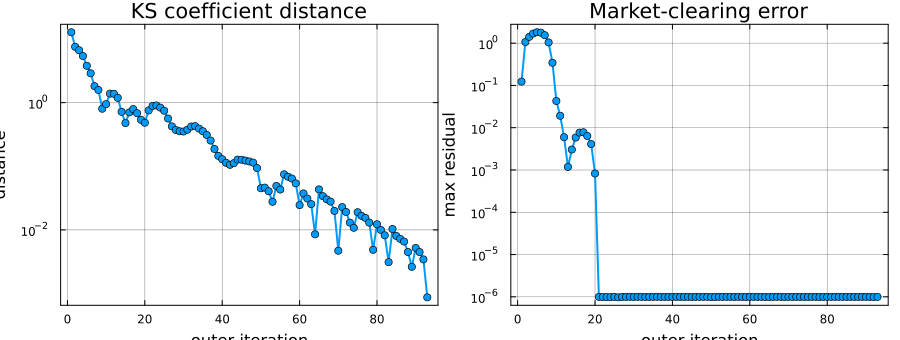

In [13]:
# Tabulate the outer iterations before plotting selected convergence criteria.
history = result.history
println(" iter | rule distance | NKPC error | EGM error | R2 wage | R2 output | max clear | clear share")
println(repeat("-", 104))
for h in history
    @printf(
        "%5d | %13.3e | %10.3e | %9.3e | %7.4f | %9.4f | %9.2e | %11.4f\n",
        h.iteration,
        h.rule_distance,
        h.nkpc_error,
        h.egm_error,
        h.wage_r_squared,
        h.output_r_squared,
        h.max_clearing_error,
        h.market_convergence_share,
    )
end

# Plot coefficient and market-clearing convergence on logarithmic scales.
convergence_plot = plot(layout=(1, 2), size=(900, 340))
plot!(
    convergence_plot[1],
    [h.rule_distance for h in history],
    marker=:circle,
    yscale=:log10,
    title="KS coefficient distance",
    xlabel="outer iteration",
    ylabel="distance",
    label=false,
)
plot!(
    convergence_plot[2],
    [h.max_clearing_error for h in history],
    marker=:circle,
    yscale=:log10,
    title="Market-clearing error",
    xlabel="outer iteration",
    ylabel="max residual",
    label=false,
)
convergence_plot


## 10. Solution checks

A credible HANK solution should verify at least:

1. the inner NKPC error;
2. the EGM policy sup norm;
3. conservation of distribution mass;
4. bond- and labor-market residuals;
5. whether realized wages or output hit grid boundaries;
6. forecasting $R^2$ and coefficient distance;
7. whether wealth accumulates at either asset boundary.


In [14]:
# Check convergence, forecasting accuracy, market clearing, mass, and grid boundaries.
summary_stats = solution_summary(result)
wealth_stats = distribution_moments(result)
forecast_stats = forecast_diagnostics(result)
sim = result.simulation

# Measure how often simulated aggregates reach interpolation-grid boundaries.
wage_boundary_share = mean(
    (sim.wage[post_burn] .<= first(result.model.wage_grid) + 1e-8) .|
    (sim.wage[post_burn] .>= last(result.model.wage_grid) - 1e-8)
)
output_boundary_share = mean(
    (sim.output[post_burn] .<= first(result.model.output_grid) + 1e-8) .|
    (sim.output[post_burn] .>= last(result.model.output_grid) - 1e-8)
)

# Report the main numerical diagnostics.
println("Solution checks")
println(repeat("-", 52))
@printf("%-31s %16.3e\n", "maximum market residual", summary_stats.max_market_residual)
@printf("%-31s %16.3f\n", "market convergence share", summary_stats.market_convergence_share)
@printf("%-31s %16.3e\n", "wage forecast RMSE (logs)", forecast_stats.wage_rmse)
@printf("%-31s %16.3e\n", "output forecast RMSE (logs)", forecast_stats.output_rmse)
@printf("%-31s %16.3f\n", "wage boundary share", wage_boundary_share)
@printf("%-31s %16.3f\n", "output boundary share", output_boundary_share)
@printf("%-31s %16.6f\n", "mean assets", wealth_stats.mean_assets)
@printf("%-31s %16.6f\n", "asset standard deviation", wealth_stats.standard_deviation_assets)
@printf("%-31s %16.6f\n", "mass at borrowing limit", wealth_stats.borrowing_constraint_mass)
@printf("%-31s %16.12f\n", "final distribution mass", sum(sim.final_distribution))

# Fail loudly when core equilibrium checks are not satisfied.
@assert isapprox(sum(sim.final_distribution), 1.0; atol=1e-10)
@assert result.converged "KS fixed point did not satisfy all stopping criteria"
@assert summary_stats.max_market_residual <= 1e-6
@assert summary_stats.market_convergence_share == 1.0


Solution checks
----------------------------------------------------
maximum market residual                9.961e-07
market convergence share                   1.000
wage forecast RMSE (logs)              1.527e-03
output forecast RMSE (logs)            3.279e-03
wage boundary share                        0.000
output boundary share                      0.000
mean assets                            -0.000000
asset standard deviation                4.165160
mass at borrowing limit                 0.000000
final distribution mass           1.000000000000


### 10.1 Post-burn simulation from the converged solution

The following figure uses only the post-burn sample from the final `result.simulation`, not the standalone diagnostic simulation under the initial aggregate rules in Section 8. For readability, it shows the first 100 post-burn periods. Wages and output are in levels; inflation and the real return are quarterly percentages.


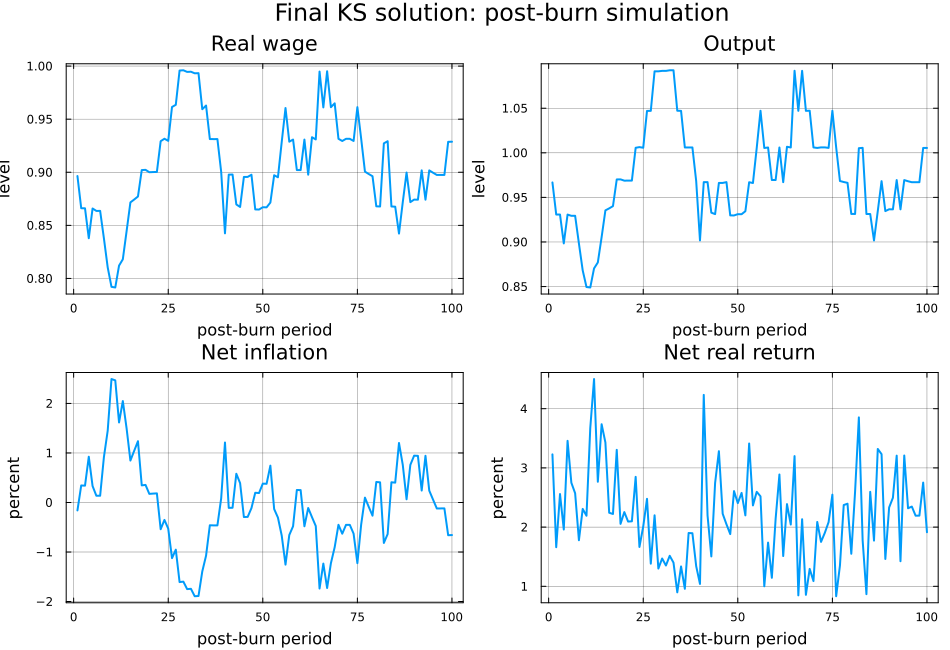

In [15]:
# Select a readable post-burn window from the final KS simulation.
post_burn_periods = (par.burn_in + 1):par.simulation_length
simulation_plot_length = min(100, length(post_burn_periods))
simulation_plot_indices =
    first(post_burn_periods):(first(post_burn_periods) + simulation_plot_length - 1)
simulation_plot_periods = 1:simulation_plot_length

# Convert gross inflation and returns to quarterly net percentages.
net_inflation_percent =
    100.0 .* (sim.inflation[simulation_plot_indices] .- 1.0)
net_real_return_percent =
    100.0 .* (sim.gross_return[simulation_plot_indices] .- 1.0)

# Plot real quantities in levels and price variables as net rates.
final_simulation_plot = plot(
    layout=(2, 2),
    size=(950, 650),
    legend=false,
    plot_title="Final KS solution: post-burn simulation",
)
plot!(
    final_simulation_plot[1],
    simulation_plot_periods,
    sim.wage[simulation_plot_indices],
    title="Real wage",
    xlabel="post-burn period",
    ylabel="level",
)
plot!(
    final_simulation_plot[2],
    simulation_plot_periods,
    sim.output[simulation_plot_indices],
    title="Output",
    xlabel="post-burn period",
    ylabel="level",
)
plot!(
    final_simulation_plot[3],
    simulation_plot_periods,
    net_inflation_percent,
    title="Net inflation",
    xlabel="post-burn period",
    ylabel="percent",
)
plot!(
    final_simulation_plot[4],
    simulation_plot_periods,
    net_real_return_percent,
    title="Net real return",
    xlabel="post-burn period",
    ylabel="percent",
)
final_simulation_plot


### 10.2 Final household policy functions

These slices use the final KS household policy with aggregate shocks fixed at their central states. Wages, output, and the inherited nominal rate equal their post-burn means in the final simulation. To prevent the sparse asset tail from compressing the figure, the plots stop at assets of 70; the policy itself is still solved on the full asset grid.


Representative state: wage=0.9026, output=0.9757, previous nominal rate=0.0207


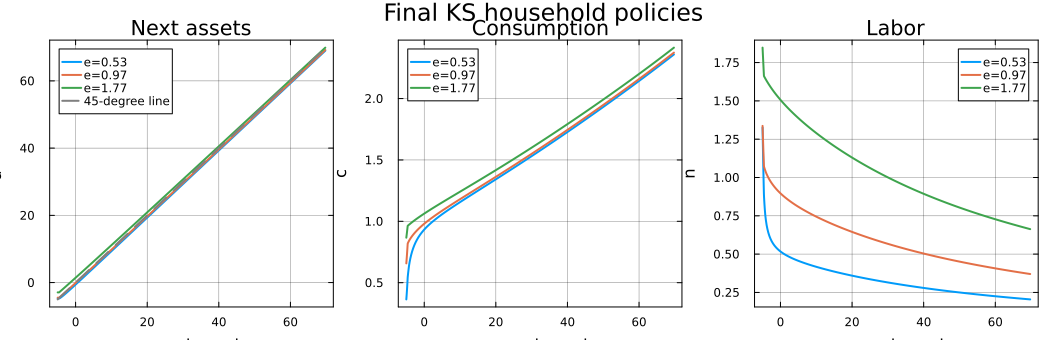

In [16]:
# Evaluate final household policies at a representative aggregate state.
representative_wage = mean(sim.wage[post_burn_periods])
representative_output = mean(sim.output[post_burn_periods])
representative_previous_nominal_rate =
    mean(sim.nominal_rate[post_burn_periods])
policy_plot_asset_max = 70.0

# Plot each efficiency state over the populated part of the asset grid.
final_policy_plot = plot(
    layout=(1, 3),
    size=(1050, 340),
    plot_title="Final KS household policies",
)
for productivity_index in 1:par.n_e
    final_policy_slice = policy_slice(
        result;
        wage=representative_wage,
        output=representative_output,
        productivity_index=productivity_index,
        previous_nominal_rate=representative_previous_nominal_rate,
    )
    visible_assets = final_policy_slice.assets .<= policy_plot_asset_max
    productivity_label =
        "e=$(round(result.model.e_grid[productivity_index], digits=2))"
    plot!(
        final_policy_plot[1],
        final_policy_slice.assets[visible_assets],
        final_policy_slice.savings[visible_assets],
        label=productivity_label,
    )
    plot!(
        final_policy_plot[2],
        final_policy_slice.assets[visible_assets],
        final_policy_slice.consumption[visible_assets],
        label=productivity_label,
    )
    plot!(
        final_policy_plot[3],
        final_policy_slice.assets[visible_assets],
        final_policy_slice.labor[visible_assets],
        label=productivity_label,
    )
end
# Add the 45-degree saving line and finalize panel labels.
visible_asset_grid =
    result.model.histogram_asset_grid[
        result.model.histogram_asset_grid .<= policy_plot_asset_max
    ]
plot!(
    final_policy_plot[1],
    visible_asset_grid,
    visible_asset_grid,
    linestyle=:dash,
    color=:gray,
    label="45-degree line",
)
plot!(
    final_policy_plot[1],
    title="Next assets",
    xlabel="current assets",
    ylabel="a'",
)
plot!(
    final_policy_plot[2],
    title="Consumption",
    xlabel="current assets",
    ylabel="c",
)
plot!(
    final_policy_plot[3],
    title="Labor",
    xlabel="current assets",
    ylabel="n",
)

# Record the aggregate state used for the policy slices.
@printf(
    "Representative state: wage=%.4f, output=%.4f, previous nominal rate=%.4f\n",
    representative_wage,
    representative_output,
    representative_previous_nominal_rate,
)
final_policy_plot


### 10.3 Ergodic wealth distribution

Finally, plot the marginal asset CDF implied by the average distribution in the final simulation. This reveals any abnormal mass near the borrowing constraint or upper asset boundary.


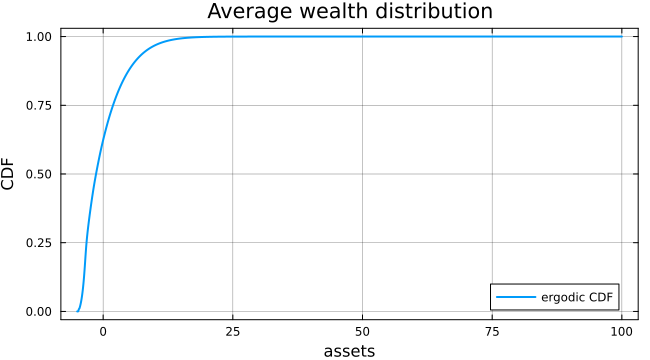

In [17]:
wealth = distribution_moments(result)
wealth_distribution_plot = plot(
    result.model.histogram_asset_grid,
    cumsum(wealth.marginal_assets),
    label="ergodic CDF",
    title="Average wealth distribution",
    xlabel="assets",
    ylabel="CDF",
    size=(650, 360),
)
wealth_distribution_plot


## 11. Simulation moments

For the post-burn simulation $t=B+1,\ldots,T$, we report the means and standard deviations of：

$$
z_t, \eta_t, w_t, Y_t, \Pi_t, i_t, R_t,\bar a_t:
$$

All variables are reported in model levels.


In [18]:
post_burn_moment_periods =
    (par.burn_in + 1):par.simulation_length

simulation_moment_series = (
    (
        "TFP, z",
        result.model.z_grid[sim.z_path[post_burn_moment_periods]],
    ),
    (
        "Monetary shock, eta",
        result.model.log_eta_grid[sim.eta_path[post_burn_moment_periods]],
    ),
    ("Real wage, w", sim.wage[post_burn_moment_periods]),
    ("Output, Y", sim.output[post_burn_moment_periods]),
    ("Gross inflation, Pi", sim.inflation[post_burn_moment_periods]),
    ("Net nominal rate, i", sim.nominal_rate[post_burn_moment_periods]),
    ("Gross real return, R", sim.gross_return[post_burn_moment_periods]),
    ("Mean assets", sim.mean_assets[post_burn_moment_periods]),
)

println("Post-burn simulation moments (levels)")
println(repeat("-", 62))
@printf("%-28s %15s %15s\n", "variable", "mean", "std. dev.")
println(repeat("-", 62))
for (label, values) in simulation_moment_series
    @printf(
        "%-28s %15.8f %15.8f\n",
        label,
        mean(values),
        std(values),
    )
end


Post-burn simulation moments (levels)
--------------------------------------------------------------
variable                                mean       std. dev.
--------------------------------------------------------------
TFP, z                            1.00366961      0.07308040
Monetary shock, eta               0.00030133      0.00208375
Real wage, w                      0.90256792      0.05247163
Output, Y                         0.97566350      0.06451178
Gross inflation, Pi               0.99858556      0.01060453
Net nominal rate, i               0.02073894      0.01581501
Gross real return, R              1.02216073      0.00821005
Mean assets                      -0.00000012      0.00000023


## 13. Generalized impulse responses to TFP and monetary-policy shocks

### 13.1 GIRF definition

Because the model is nonlinear and the wealth distribution is part of the aggregate state, an impulse response depends on the initial state

$$
\Omega_0=(\bar\mu,z_0,\eta_0,i_{-1}).
$$

For any aggregate variable $q$, the generalized impulse response is

$$
\operatorname{GIRF}_{q}(h;\delta,\Omega_0)
=
\mathbb E\!\left[
q_h^{\delta}-q_h^{0}
\mid \Omega_0
\right],
\qquad h=0,\ldots,H-1.
$$

The shocked and baseline economies start from the same state and receive the same future aggregate-shock draws; they differ only by the impact shock $\delta$. We consider a positive TFP shock, which raises $z_0$, and a positive monetary-policy shock, which raises $\eta_0$ and is contractionary. Both experiments use the mean ergodic distribution $\bar\mu$, a horizon of $H=40$, and $N=2{,}000$ paired paths. The shaded bands report 90% Monte Carlo intervals.

The timing of the realized real return remains

$$
R_t=\frac{1+i_{t-1}}{\Pi_t}.
$$

Thus a monetary-policy shock changes $i_0$ on impact, while its direct Fisher effect appears in $R_1$; $R_0$ can still move through current inflation $\Pi_0$.


In [19]:
# Compute paired-path GIRFs with common random numbers to reduce Monte Carlo noise.
girf_horizon = 40
girf_paths = 2_000
girf_cache_path = joinpath(
    cache_dir,
    "girf_resource_cost_dividends_h$(girf_horizon)_paths$(girf_paths).jls",
)

if !result.converged
    @warn(
        "The resource-cost-dividend KS experiment stopped before convergence; " *
        "these GIRFs describe the current intermediate solution.",
    )
end

# Compute both shocks with fixed seeds so the experiment is reproducible.
function compute_girfs()
    println("Computing positive TFP GIRF...")
    tfp = generalized_irf(
        result;
        shock=:tfp,
        shock_size_innovations=1.0,
        direction=1,
        horizon=girf_horizon,
        n_paths=girf_paths,
        seed=2025,
    )

    println("Computing positive monetary-policy GIRF (contractionary)...")
    monetary = generalized_irf(
        result;
        shock=:monetary,
        shock_size_innovations=1.0,
        direction=1,
        horizon=girf_horizon,
        n_paths=girf_paths,
        seed=7171,
    )

    # Store GIRFs with every input needed for compatibility checks.
    cache_entry = (
        params=result.params,
        wage_coefficients=copy(result.rules.wage.coefficient),
        output_coefficients=copy(result.rules.output.coefficient),
        horizon=girf_horizon,
        n_paths=girf_paths,
        tfp=tfp,
        monetary=monetary,
    )
    serialize(girf_cache_path, cache_entry)
    return cache_entry
end

# Recompute automatically when the solution or experiment design changes.
girf_results = if isfile(girf_cache_path)
    try
        cache_entry = deserialize(girf_cache_path)
        cache_matches =
            cache_entry.params == result.params &&
            cache_entry.wage_coefficients == result.rules.wage.coefficient &&
            cache_entry.output_coefficients == result.rules.output.coefficient &&
            cache_entry.horizon == girf_horizon &&
            cache_entry.n_paths == girf_paths
        cache_matches || error("cached GIRFs belong to another HANK solution")
        println("Loading cached GIRFs from ", girf_cache_path)
        cache_entry
    catch err
        @warn "GIRF cache is stale; computing again" exception=(
            err,
            catch_backtrace(),
        )
        compute_girfs()
    end
else
    compute_girfs()
end

# Expose both experiments and report their realized impact sizes.
tfp_girf = girf_results.tfp
monetary_girf = girf_results.monetary

@printf(
    "TFP impact:      %+.3f innovation sd (%+.4f log points)\n",
    tfp_girf.impact_innovation_sd,
    tfp_girf.impact_log_shock,
)
@printf(
    "Monetary impact: %+.3f innovation sd (%+.6f log points)\n",
    monetary_girf.impact_innovation_sd,
    monetary_girf.impact_log_shock,
)

Computing positive TFP GIRF...
GIRF tfp      | impact = +1.376 innovation sd | horizon = 40 | paths = 2000 | threads = 16
GIRF completed in 8.90 seconds
Computing positive monetary-policy GIRF (contractionary)...
GIRF monetary | impact = +1.376 innovation sd | horizon = 40 | paths = 2000 | threads = 16
GIRF completed in 7.72 seconds
TFP impact:      +1.376 innovation sd (+0.0420 log points)
Monetary impact: +1.376 innovation sd (+0.001200 log points)


### 13.2 Plot units and confidence bands

All six panels use the following transformations for each shock:

| Panel | Transformation | Unit |
|---|---:|---|
| Exogenous shock | $100\,\Delta\log z$ or $100\Delta\eta$ | percent / percent equivalent |
| Output and real wage | $100(q^{s}/q^{b}-1)$ | percent deviation |
| Inflation | $100(\Pi^{s}-\Pi^{b})$ | percentage points |
| Nominal interest rate | $100(i^{s}-i^{b})$ | percentage points |
| Realized real return | $100(R^{s}-R^{b})$ | percentage points |

The shaded region is $\widehat{\operatorname{GIRF}}\pm1.645\,\widehat{\mathrm{SE}}$, a 90% Monte Carlo interval computed from 2,000 paired differences.


In [20]:
# Convert every GIRF object to the same six-panel presentation.
function plot_girf(
    girf;
    shock_kind::Symbol,
    figure_title::String,
)
    shock_kind in (:tfp, :monetary) ||
        error("shock_kind must be :tfp or :monetary")

    periods = 0:(girf.horizon - 1)
    critical_value = 1.645
    # Only the shock panel differs; the five equilibrium panels are shared.
    shock_item = if shock_kind == :tfp
        (key=:log_tfp, title="TFP shock", ylabel="percent", scale=100.0)
    else
        (
            key=:log_monetary,
            title="Monetary-policy shock",
            ylabel="percent-equivalent",
            scale=100.0,
        )
    end
    panels = (
        shock_item,
        (key=:output, title="Output", ylabel="percent", scale=100.0),
        (key=:wage, title="Real wage", ylabel="percent", scale=100.0),
        (
            key=:inflation,
            title="Gross inflation",
            ylabel="percentage points",
            scale=100.0,
        ),
        (
            key=:nominal_rate,
            title="Net nominal rate",
            ylabel="percentage points",
            scale=100.0,
        ),
        (
            key=:real_return,
            title="Realized gross real return",
            ylabel="percentage points",
            scale=100.0,
        ),
    )

    # Use one color per shock and a common layout across experiments.
    color = shock_kind == :tfp ? :steelblue : :firebrick
    figure = plot(
        layout=(2, 3),
        size=(1050, 620),
        plot_title=figure_title,
        legend=false,
    )

    # Scale responses, attach 90% Monte Carlo bands, and add zero lines.
    for (panel_index, item) in enumerate(panels)
        response =
            item.scale .* getproperty(girf.response, item.key)
        uncertainty =
            critical_value .* item.scale .* getproperty(
                girf.monte_carlo_se,
                item.key,
            )
        plot!(
            figure[panel_index],
            periods,
            response,
            ribbon=uncertainty,
            color=color,
            fillalpha=0.18,
            label="GIRF (90% MC band)",
            title=item.title,
            xlabel=panel_index >= 4 ? "periods after impact" : "",
            ylabel=item.ylabel,
            xlims=(0, girf.horizon - 1),
        )
        hline!(
            figure[panel_index],
            [0.0],
            color=:gray,
            linestyle=:dot,
            linewidth=1,
            label="",
        )
    end
    return figure
end

plot_girf (generic function with 1 method)

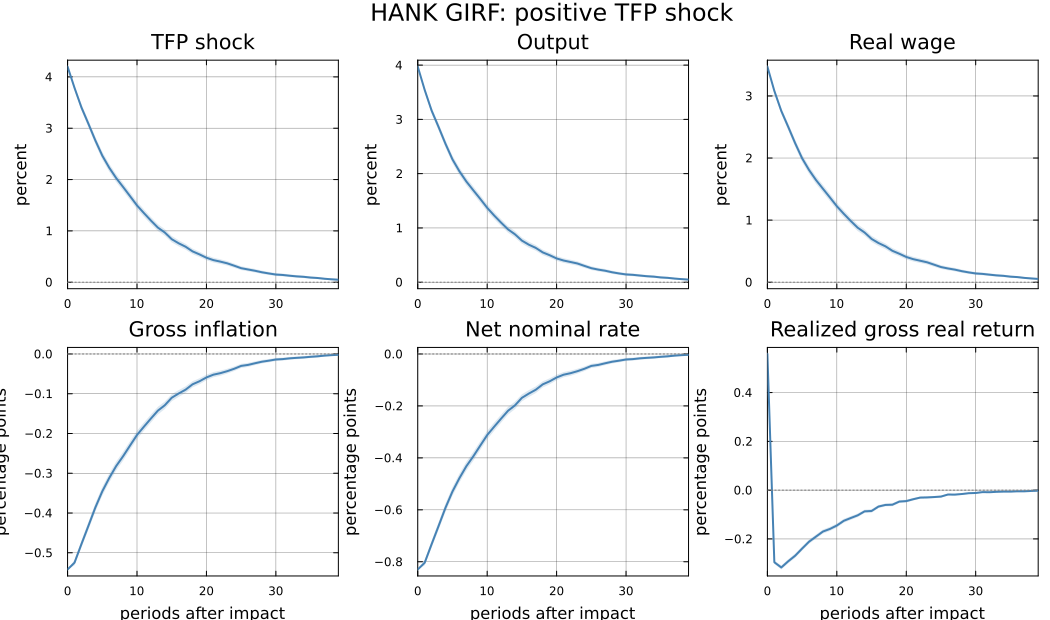

In [21]:
tfp_girf_plot = plot_girf(
    tfp_girf;
    shock_kind=:tfp,
    figure_title="HANK GIRF: positive TFP shock",
)
tfp_girf_plot

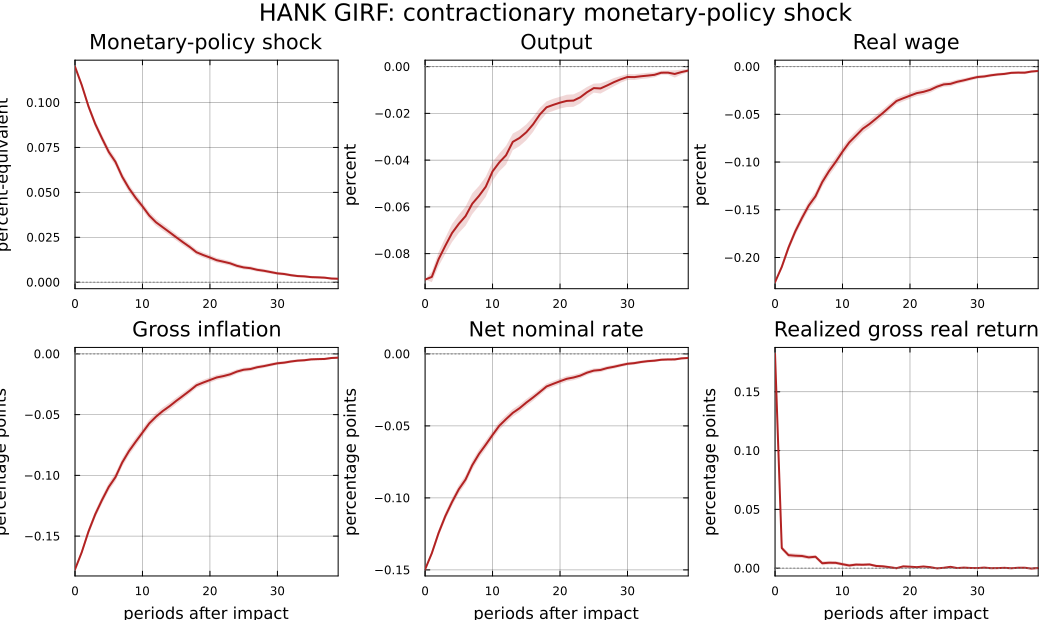

In [22]:
monetary_girf_plot = plot_girf(
    monetary_girf;
    shock_kind=:monetary,
    figure_title="HANK GIRF: contractionary monetary-policy shock",
)
monetary_girf_plot